In [54]:
# Imports
# If any of these imports do not work, do "!pip install [package]"
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.inference import ExactInference, VariableElimination

import networkx as nx

### Data Sourcing and Processing

https://www.kaggle.com/datasets/khansaafreen/breastdataset

This dataset contains 569 samples with 30 numeric features. The features describe the attributes of a tumor and the target label is whether a tumor is benign or malignant.

In [55]:
# Dataset path: download the dataset from https://www.kaggle.com/datasets/khansaafreen/breastdataset
# Copy and paste the "data.csv" file from the "archive.zip" file into the same folder where "Final_Project.ipynb" is located
path = "data.csv"

In [56]:
df = pd.read_csv(path)
df = df.drop('Unnamed: 32', axis=1)

In [57]:
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [58]:
# Encode categorical data (just the target label)
label_encoder = LabelEncoder()

for column in df.select_dtypes(include=['object']).columns:
    df[column] = label_encoder.fit_transform(df[column])

In [59]:
# drop the id column
df = df.drop('id', axis=1)
df.head(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Index([0, 1], dtype='int64', name='diagnosis')


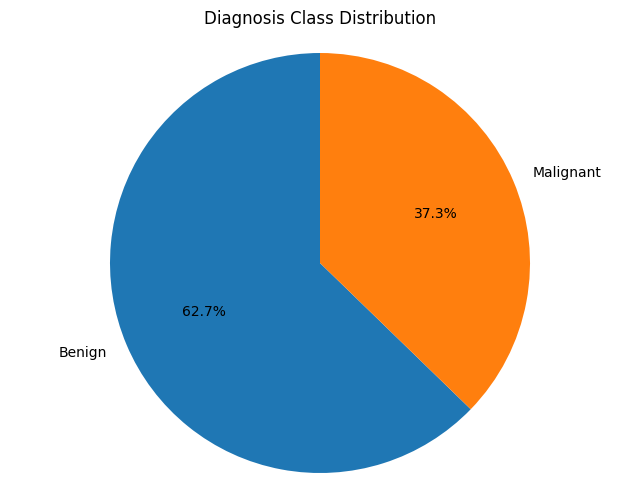

In [60]:
# whether there is class imbalance in the dataset
labels = df['diagnosis'].value_counts()
plt.figure(figsize=(8, 6))
print(labels.index)
plt.pie(labels.values, labels=["Benign", "Malignant"], autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Diagnosis Class Distribution')
plt.show()

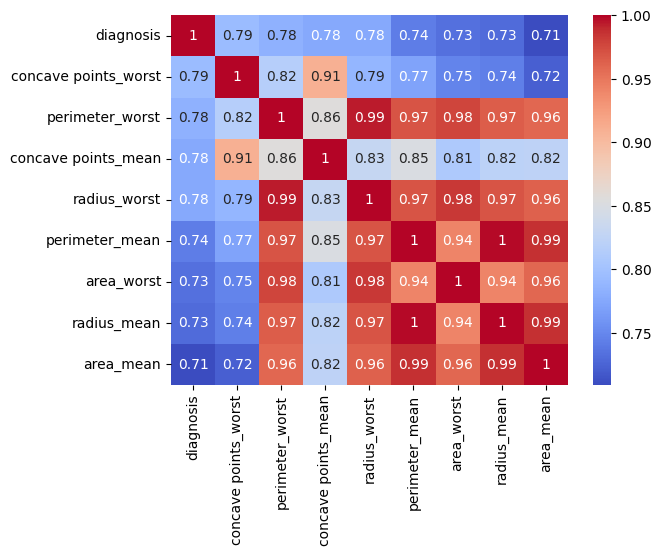

In [61]:
target = "diagnosis"
X = df.drop(target, axis=1)
y = df[target]

corr_matrix = df.corr()

target_corr = corr_matrix[target].sort_values(ascending=False)

# only show the features highly correlated with the target
high_corr = target_corr[abs(target_corr) > 0.7].index
sns.heatmap(corr_matrix.loc[high_corr, high_corr], annot=True, cmap="coolwarm")
plt.show()

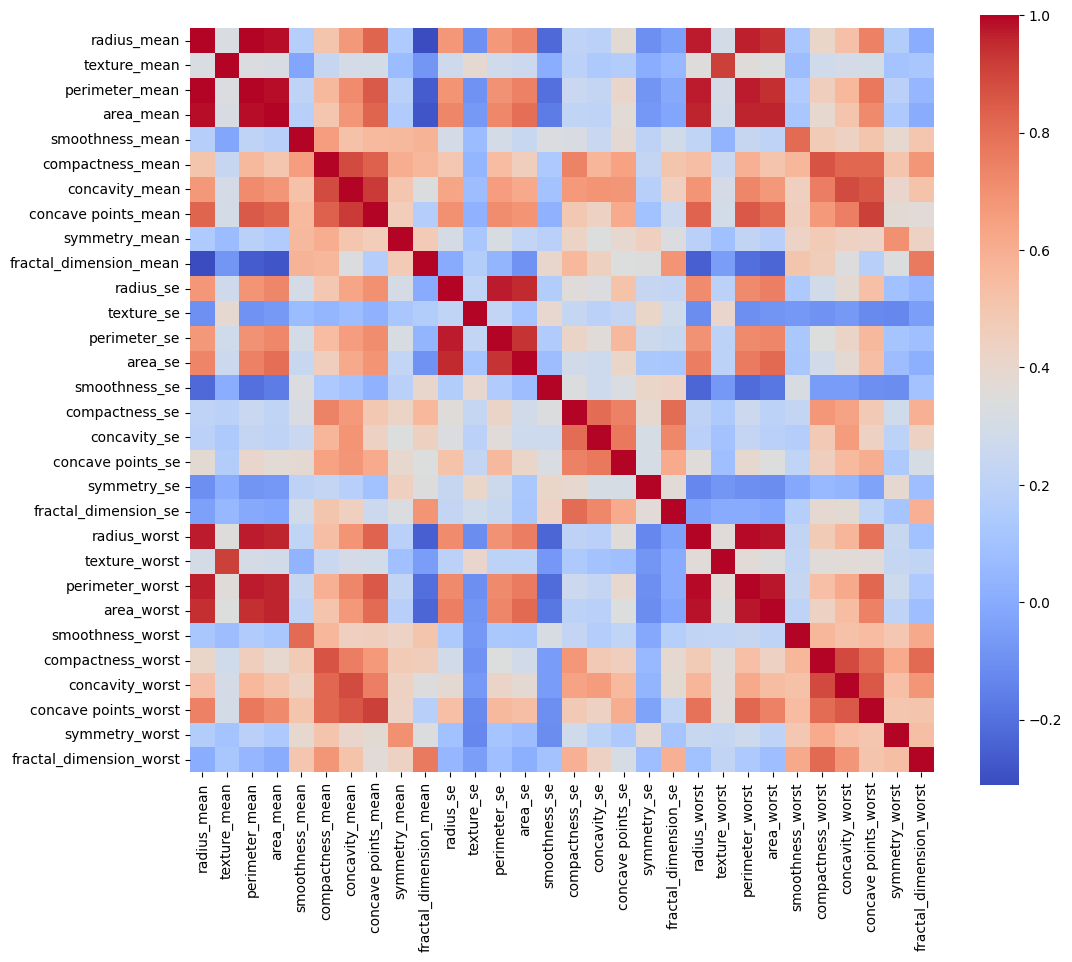

In [62]:
corr_matrix_without_target = corr_matrix.drop(columns=[target]).drop(index=[target])
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_without_target, annot=False, cmap="coolwarm", square=True)
plt.show()

In [63]:
# list the highly correlated features, and group them together
highly_correlated_feature_groups = []
threshold = 0.9
cols = corr_matrix_without_target.columns
n = len(cols)

for i in range(n):
    for j in range(i + 1, n):
        val = corr_matrix_without_target.iloc[i, j]
        if abs(val) > threshold:
            feature1 = cols[i]
            feature2 = cols[j]
            
            merged_group = {feature1, feature2}
            remaining_groups = []
            
            for group in highly_correlated_feature_groups:
                if feature1 in group or feature2 in group:
                    merged_group.update(group)
                else:
                    remaining_groups.append(group)
            highly_correlated_feature_groups = remaining_groups + [merged_group]

for idx, group in enumerate(highly_correlated_feature_groups):
    print(f"Group {idx + 1}: {group}")


Group 1: {'texture_mean', 'texture_worst'}
Group 2: {'concavity_mean', 'concave points_mean', 'concave points_worst'}
Group 3: {'area_se', 'radius_se', 'perimeter_se'}
Group 4: {'perimeter_worst', 'perimeter_mean', 'area_worst', 'area_mean', 'radius_worst', 'radius_mean'}


In [64]:
high_corr

Index(['diagnosis', 'concave points_worst', 'perimeter_worst',
       'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst',
       'radius_mean', 'area_mean'],
      dtype='object')

In [65]:
# took the top features based on correlation score (anything above 0.5 correlation)
top_features = [feat for feat in high_corr if feat != 'diagnosis']

top_features_target = top_features.copy()
top_features_target.append(target)

top_df = df[top_features_target]

display(top_df)

,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,area_worst,radius_mean,area_mean,diagnosis
0,0.2654,184.60,0.14710,25.380,122.80,2019.0,17.99,1001.0,1
1,0.1860,158.80,0.07017,24.990,132.90,1956.0,20.57,1326.0,1
2,0.2430,152.50,0.12790,23.570,130.00,1709.0,19.69,1203.0,1
3,0.2575,98.87,0.10520,14.910,77.58,567.7,11.42,386.1,1
4,0.1625,152.20,0.10430,22.540,135.10,1575.0,20.29,1297.0,1
...,...,...,...,...,...,...,...,...,...
564,0.2216,166.10,0.13890,25.450,142.00,2027.0,21.56,1479.0,1
565,0.1628,155.00,0.09791,23.690,131.20,1731.0,20.13,1261.0,1
566,0.1418,126.70,0.05302,18.980,108.30,1124.0,16.60,858.1,1
567,0.2650,184.60,0.15200,25.740,140.10,1821.0,20.60,1265.0,1


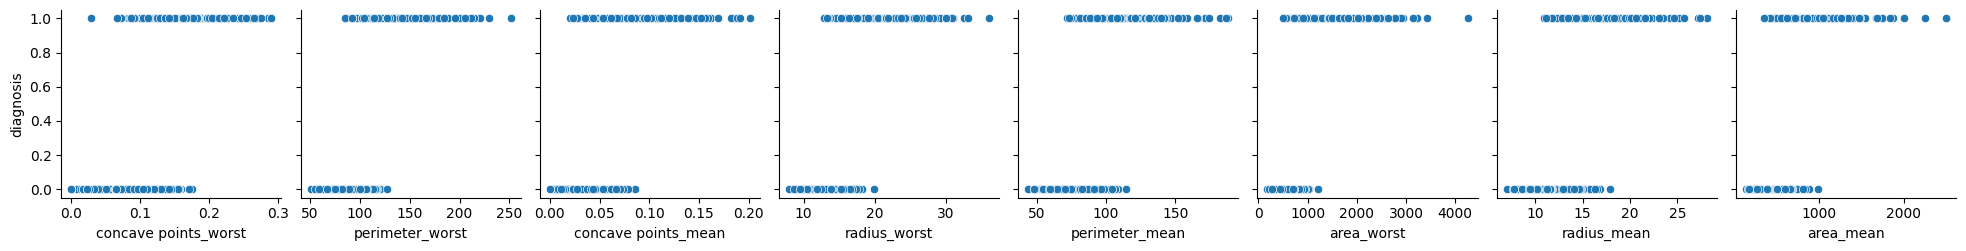

In [66]:
sns.pairplot(data=df, x_vars=top_features, y_vars=[target])

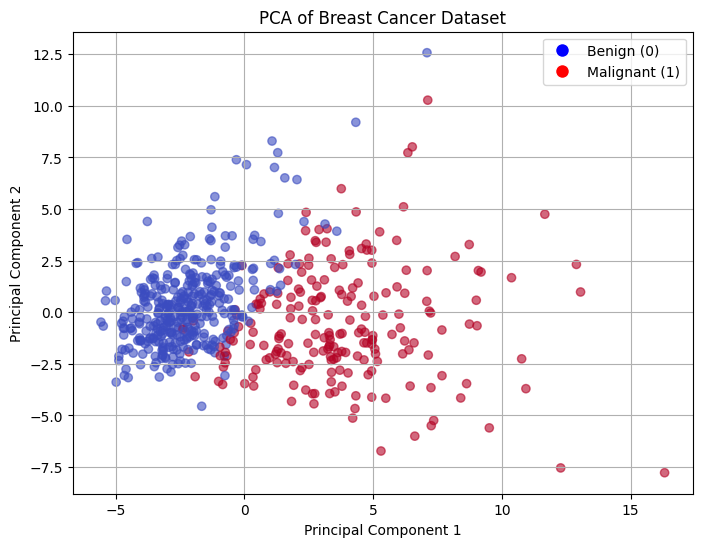

In [67]:
from sklearn.discriminant_analysis import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Breast Cancer Dataset')

plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w', label='Benign (0)', 
                markerfacecolor='blue', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Malignant (1)', 
                markerfacecolor='red', markersize=10)
])
plt.grid(True)
plt.show()

# Discretization

In [68]:
def assign_equal_frequency_bins(data_array: np.ndarray, num_bins: int) -> np.ndarray:
    """
    assign [0, num_bins-1] bin indices to data_array based on equal frequency binning.
    For example, when num_bins=3, the smallest 1/3 values are assigned to bin 0,
    the middle 1/3 values are assigned to bin 1, and the largest 1/3 values are assigned to bin 2.
    """
    
    quantiles = np.linspace(0.0, 1.0, num_bins + 1)
    bins = np.quantile(data_array, quantiles)
    
    bin_indices = pd.cut(
        data_array, 
        bins=bins, 
        labels=False, 
        include_lowest=True,
        right=True
    ).astype(int)
    return bin_indices

top_df = df[top_features_target].copy()
for feat in top_features:
    top_df[feat] = assign_equal_frequency_bins(top_df[feat].to_numpy(), num_bins=3)

### Modeling and Inference

In [69]:
X = top_df.drop(target, axis=1)
y = top_df[target]

display(X)
display(y)

,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,area_worst,radius_mean,area_mean
0,2,2,2,2,2,2,2,2
1,2,2,2,2,2,2,2,2
2,2,2,2,2,2,2,2,2
3,2,1,2,1,0,1,0,0
4,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...
564,2,2,2,2,2,2,2,2
565,2,2,2,2,2,2,2,2
566,1,2,1,2,2,2,2,2
567,2,2,2,2,2,2,2,2


0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [71]:
# baseline
import random

random.seed(42)

predictions = []

baseline = X_test.apply(lambda row: row.value_counts(), axis=1)
baseline.fillna(0, inplace=True)

benign = list(baseline[0])
malignant = list(baseline[2])

for i in range(len(benign)):
    if benign[i] > malignant[i]:
        predictions.append(0)
    elif malignant[i] > benign[i]:
        predictions.append(1)
    else:
        if random.random() <= (df['diagnosis'].value_counts()[0] / sum(df['diagnosis'].value_counts())):
            predictions.append(0)
        else:
            predictions.append(1)

In [72]:
# baseline evaluation
acc = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.8772
Precision: 0.7843
Recall: 0.9302
F1 Score: 0.8511


In [73]:
tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

print(tn)
print(fp)
print(fn)
print(tp)

60
11
3
40


In [74]:
fpr = fp / (tn + fp)
fnr = fn / (fn + tp)

print(fpr)
print(fnr)

0.15492957746478872
0.06976744186046512


In [75]:
X_test

,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,area_worst,radius_mean,area_mean
204,1,1,1,1,1,1,1,1
70,2,2,2,2,2,2,2,2
131,2,2,2,2,2,2,2,2
431,0,1,1,0,1,0,1,1
540,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...
486,0,1,1,1,1,1,1,1
75,2,2,2,2,2,2,2,2
249,1,0,1,0,0,0,0,0
238,1,1,1,1,1,1,1,1


In [76]:
train = X_train.copy()

In [77]:
train['diagnosis'] = y_train

In [78]:
train

,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,area_worst,radius_mean,area_mean,diagnosis
68,2,0,1,0,0,0,0,0,0
181,2,2,2,2,2,2,2,2,1
63,0,0,0,0,0,0,0,0,0
248,0,0,0,0,0,0,0,0,0
60,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...
71,0,0,1,0,0,0,0,0,0
106,1,0,1,0,0,0,0,0,0
270,0,1,0,1,1,1,1,1,0
435,2,2,2,2,1,2,1,1,1


In [79]:
X_train

,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,area_worst,radius_mean,area_mean
68,2,0,1,0,0,0,0,0
181,2,2,2,2,2,2,2,2
63,0,0,0,0,0,0,0,0
248,0,0,0,0,0,0,0,0
60,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
71,0,0,1,0,0,0,0,0
106,1,0,1,0,0,0,0,0
270,0,1,0,1,1,1,1,1
435,2,2,2,2,1,2,1,1


In [80]:
y_train

68     0
181    1
63     0
248    0
60     0
      ..
71     0
106    0
270    0
435    1
102    0
Name: diagnosis, Length: 455, dtype: int64

In [81]:
model = DiscreteBayesianNetwork()

for feat in top_features:
    model.add_edge(feat, target)

print(model.edges)

[('concave points_worst', 'diagnosis'), ('perimeter_worst', 'diagnosis'), ('concave points_mean', 'diagnosis'), ('radius_worst', 'diagnosis'), ('perimeter_mean', 'diagnosis'), ('area_worst', 'diagnosis'), ('radius_mean', 'diagnosis'), ('area_mean', 'diagnosis')]


In [82]:
model.fit(train, estimator=MaximumLikelihoodEstimator)

model.check_model()

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'concave points_worst': 'N', 'perimeter_worst': 'N', 'concave points_mean': 'N', 'radius_worst': 'N', 'perimeter_mean': 'N', 'area_worst': 'N', 'radius_mean': 'N', 'area_mean': 'N', 'diagnosis': 'N'}


True

In [83]:
inference = VariableElimination(model)

predictions = []

for index, row in X_test.iterrows():
    evidence = row.to_dict()

    prediction = inference.query(variables=[target], evidence=evidence)

    prob_malignant = prediction.values[1]

    predicted_class = 1 if prob_malignant > 0.3 else 0
    predictions.append(predicted_class)

In [84]:
accuracy_indep = accuracy_score(y_test, predictions)
precision_indep = precision_score(y_test, predictions)
recall_indep = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print(f"Accuracy: {accuracy_indep:.4f}")
print(f"Precision: {precision_indep:.4f}")
print(f"Recall: {recall_indep:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9035
Precision: 0.8333
Recall: 0.9302
F1 Score: 0.8791


In [85]:
tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

print(tn)
print(fp)
print(fn)
print(tp)

63
8
3
40


In [86]:
fpr_indep = fp / (tn + fp)
fnr_indep = fn / (fn + tp)

print(f"FPR: {fpr_indep:.4f}")
print(f"FNR: {fnr_indep:.4f}")

FPR: 0.1127
FNR: 0.0698


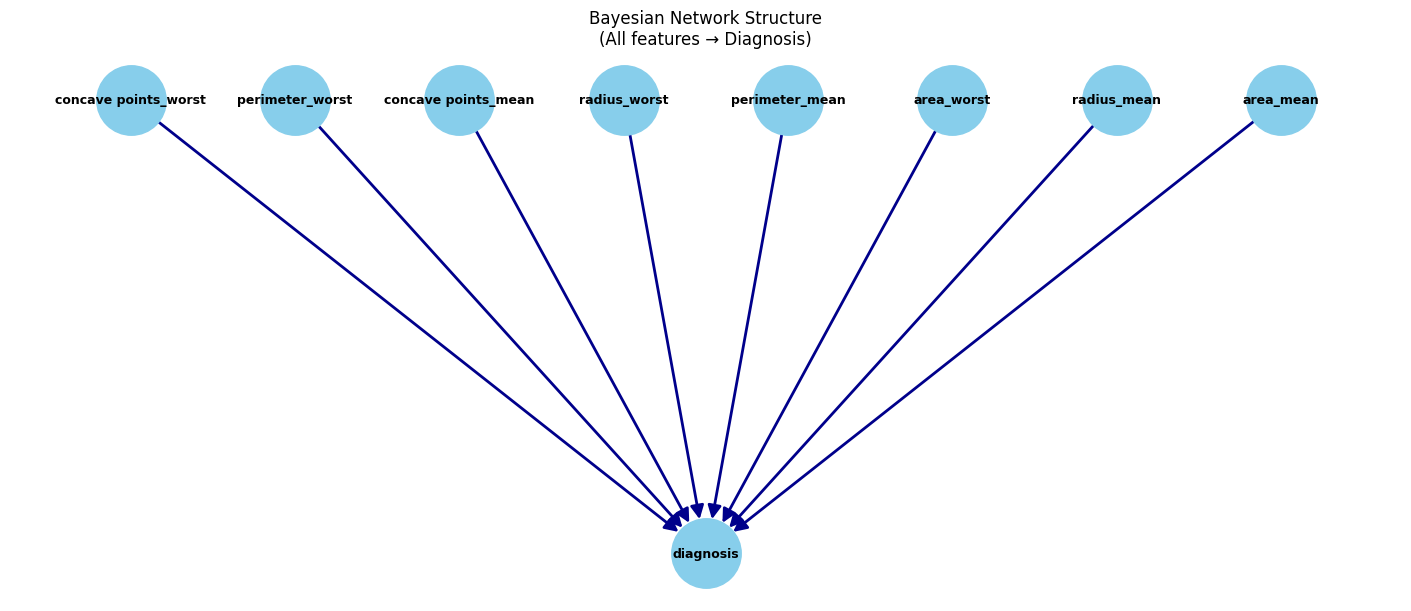

In [87]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph(model.edges())

pos = {}
features = [node for node in G.nodes() if node != 'diagnosis']
for i, feat in enumerate(features):
    pos[feat] = (i, 1)  # Top row
pos['diagnosis'] = ((len(features)-1)/2, 0) 

fig, ax = plt.subplots(constrained_layout=True, figsize=(14, 6))
nx.draw(G, pos, with_labels=True, node_color='skyblue',
        node_size=2500, font_size=9, font_weight='bold',
        arrows=True, arrowsize=20, edge_color='darkblue', width=2)
ax.set_title('Bayesian Network Structure\n(All features → Diagnosis)')
plt.show()

In [88]:
model_dependent = DiscreteBayesianNetwork()

model_dependent.add_edge('concave points_worst', 'concave points_mean')
model_dependent.add_edge('perimeter_worst', 'perimeter_mean')
model_dependent.add_edge('radius_worst', 'radius_mean')
model_dependent.add_edge('area_worst', 'area_mean')

model_dependent.add_edge('concave points_mean', target)
model_dependent.add_edge('perimeter_mean', target)
model_dependent.add_edge('radius_mean', target)
model_dependent.add_edge('area_mean', target)

print(model_dependent.edges)

[('concave points_worst', 'concave points_mean'), ('concave points_mean', 'diagnosis'), ('perimeter_worst', 'perimeter_mean'), ('perimeter_mean', 'diagnosis'), ('radius_worst', 'radius_mean'), ('radius_mean', 'diagnosis'), ('area_worst', 'area_mean'), ('area_mean', 'diagnosis')]


In [89]:
model_dependent.fit(train, estimator=MaximumLikelihoodEstimator)

model_dependent.check_model()

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'concave points_worst': 'N', 'perimeter_worst': 'N', 'concave points_mean': 'N', 'radius_worst': 'N', 'perimeter_mean': 'N', 'area_worst': 'N', 'radius_mean': 'N', 'area_mean': 'N', 'diagnosis': 'N'}


True

In [90]:
inference = VariableElimination(model_dependent)

predictions = []

for index, row in X_test.iterrows():
    evidence = row.to_dict()

    prediction = inference.query(variables=[target], evidence=evidence)

    prob_malignant = prediction.values[1]

    predicted_class = 1 if prob_malignant > 0.3 else 0
    predictions.append(predicted_class)

In [91]:
# dependence model evaluation
accuracy_dep = accuracy_score(y_test, predictions)
precision_dep = precision_score(y_test, predictions)
recall_dep = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
print(f"Accuracy: {accuracy_dep:.4f}")
print(f"Precision: {precision_dep:.4f}")
print(f"Recall: {recall_dep:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.9123
Precision: 0.8667
Recall: 0.9070
F1 Score: 0.8864


In [92]:
tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

print(tn)
print(fp)
print(fn)
print(tp)

65
6
4
39


In [93]:
fpr = fp / (tn + fp)
fnr = fn / (fn + tp)

print(fpr)
print(fnr)

0.08450704225352113
0.09302325581395349


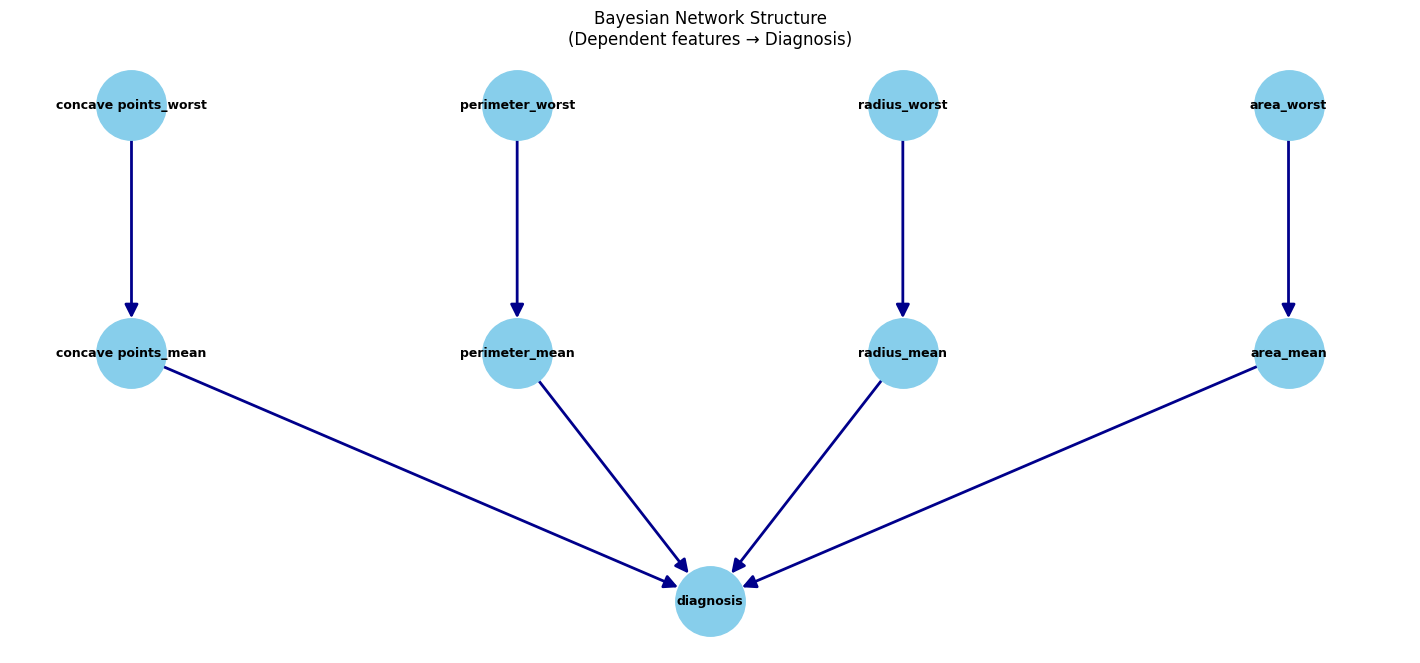

In [94]:
G = nx.DiGraph(model_dependent.edges())

pos = {}
features = [node for node in G.nodes() if node != 'diagnosis']
for i, feat in enumerate(features):
    if 'worst' in feat:
        pos[feat] = (i, 2)  # Top row
    else:
        pos[feat] = (i-1, 1)  # Second row
pos['diagnosis'] = (len(features)/2-1, 0) 

plt.figure(figsize=(14, 6))
nx.draw(G, pos, with_labels=True, node_color='skyblue',
        node_size=2500, font_size=9, font_weight='bold',
        arrows=True, arrowsize=20, edge_color='darkblue', width=2)
plt.title('Bayesian Network Structure\n(Dependent features → Diagnosis)')
plt.show()

In [95]:
print(top_features)

['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean']


In [96]:
tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

print(tn)
print(fp)
print(fn)
print(tp)

65
6
4
39


In [97]:
fpr_dep = fp / (tn + fp)
fnr_dep = fn / (fn + tp)

print(f"FPR: {fpr_dep:.4f}")
print(f"FNR: {fnr_dep:.4f}")

FPR: 0.0845
FNR: 0.0930


# ANOTHER MODEL: Using Hidden Variables as the cluster nodes

In [98]:
hv_root_node = 'diagnosis'
hv_hidden_cluster_node = "z"
hv_features = top_features.copy()

In [99]:
class HVmodel_vectorized:
    def __init__(self, root_node, hidden_cluster_node, features, k=8, feature_bins=3):
        """
        Vectorized HVmodel
        root_node: str
        hidden_cluster_node: str
        features: list of str
        k: int, number of clusters for hidden variables
        feature_bins: int, number of discrete bins for each feature (values assumed 0..feature_bins-1)
        """
        self.root_node = root_node
        self.hidden_cluster_node = hidden_cluster_node
        self.features = features
        self.k = k
        self.feature_bins = feature_bins

        # vectorized CPTs (initialized at fit time)
        self.cpt_feature_hidden = None  # shape (F, k, feature_bins), F = number of features
        self.cpt_hidden_root = None     # shape (k, R), R = number of root values

        # mapping for root values -> indices (filled at fit time)
        self.root_values = None
        self.root_val_to_idx = None

    def fit(self, training_data: pd.DataFrame, max_iterations=100, random_state=42):
        """Use EM algorithm to fit the model"""
        np.random.seed(random_state)

        # convert to numpy arrays once
        X = training_data[self.features].to_numpy(dtype=np.int64)  # shape (N, F)
        Y_vals = training_data[self.root_node].to_numpy()         # shape (N,)

        # build mapping for root values in the same order as pandas.unique(). By default, it is [0, 1]
        root_vals = training_data[self.root_node].unique()
        self.root_values = list(root_vals)
        self.root_val_to_idx = {v: i for i, v in enumerate(self.root_values)}
        Y_idx = np.vectorize(self.root_val_to_idx.get)(Y_vals)  # shape (N,)

        N, F = X.shape
        R = len(self.root_values)
        k = self.k
        bins = self.feature_bins

        # initialize parameters
        self._initialize_parameters(F, k, bins, R)

        for iteration in range(max_iterations):
            hidden_posteriors = self._e_step_vectorized(X, Y_idx)  # shape (N, k)
            self._m_step_vectorized(X, Y_idx, hidden_posteriors)

            if iteration % 20 == 0 or iteration == max_iterations - 1:
                ll = self._compute_log_likelihood_vectorized(X, Y_idx)
                print(f"Iteration {iteration}: Log-likelihood = {ll:.4f}")

    def _initialize_parameters(self, F, k, bins, R):
        """
        Randomly initialize parameters (vectorized CPTs)
        F: int, number of features
        k: int, number of hidden states
        bins: int, number of discrete bins for each feature
        R: int, number of root values
        """
        # P(feature | hidden): shape (F, k, bins)
        # For each feature f and hidden state h, sample dirichlet(bins)
        cpt_f_h = np.zeros((F, k, bins), dtype=float)
        for f in range(F):
            for h in range(k):
                cpt_f_h[f, h, :] = np.random.dirichlet([1.0] * bins)
        self.cpt_feature_hidden = cpt_f_h

        # P(root | hidden): shape (k, R)
        cpt_h_r = np.zeros((k, R), dtype=float)
        for h in range(k):
            cpt_h_r[h, :] = np.random.dirichlet([1.0] * R)
        self.cpt_hidden_root = cpt_h_r

    def _e_step_vectorized(self, X, Y_idx):
        """
        Vectorized E-step:
        Compute posterior P(hidden | features, root) for all samples simultaneously.
        Returns: hidden_posteriors shape (N, k)
        """
        eps = 1e-12
        N, F = X.shape
        k = self.k

        # compute log P(features | hidden) for all samples and hidden states
        # result shape (N, k)
        logPfeat = np.zeros((N, k), dtype=float)
        for f in range(F):
            # probs: shape (k, bins)
            probs = self.cpt_feature_hidden[f]  # (k, bins)
            cols = X[:, f]                      # (N,)
            vals = probs[:, cols].T + eps # probs[:, cols] -> shape (k, N); transpose -> (N, k)
            logPfeat += np.log(vals)

        # compute log P(root | hidden) for each sample
        # cpt_hidden_root: (k, R)
        vals_r = self.cpt_hidden_root[:, Y_idx]  # (k, N)
        logPr = np.log(vals_r.T + eps)          # (N, k)

        log_joint = logPfeat + logPr  # (N, k)

        # normalize to get posteriors (use log-sum-exp)
        max_log = np.max(log_joint, axis=1, keepdims=True)  # (N,1)
        exps = np.exp(log_joint - max_log)                  # (N,k)
        denom = exps.sum(axis=1, keepdims=True) + eps
        post = exps / denom  # (N,k)

        return post

    def _m_step_vectorized(self, X, Y_idx, post):
        """
        Vectorized M-step:
        Update self.cpt_feature_hidden and self.cpt_hidden_root from posteriors.
        post: shape (N, k)
        """
        eps = 1e-10
        N, F = X.shape
        k = self.k
        bins = self.feature_bins
        R = len(self.root_values)

        # Update P(feature | hidden)
        # For each feature f, build one-hot (N, bins), then compute counts = V.T @ post => (bins, k)
        new_cpt_f_h = np.zeros((F, k, bins), dtype=float)
        for f in range(F):
            # V: (N, bins) boolean -> float
            # we will construct with broadcasting to avoid large loops
            # approach: for bins small, building V is fine
            Xcol = X[:, f]  # (N,)
            # create one-hot for this feature: shape (N, bins)
            V = (Xcol[:, None] == np.arange(bins)[None, :]).astype(float)  # (N, bins)
            # counts_bins_k = V.T @ post -> (bins, k)
            counts = V.T @ post  # (bins, k)
            # transpose to (k, bins)
            counts = counts.T + eps
            # normalize per hidden-state
            counts /= counts.sum(axis=1, keepdims=True)
            new_cpt_f_h[f] = counts

        self.cpt_feature_hidden = new_cpt_f_h

        # Update P(root | hidden)
        # Build Y one-hot: (N, R)
        Y_onehot = np.zeros((N, R), dtype=float)
        Y_onehot[np.arange(N), Y_idx] = 1.0
        # counts_root = Y_onehot.T @ post -> (R, k), transpose -> (k, R)
        counts_root = (Y_onehot.T @ post).T + eps
        counts_root /= counts_root.sum(axis=1, keepdims=True)
        self.cpt_hidden_root = counts_root

    def _compute_log_likelihood_vectorized(self, X, Y_idx):
        """Compute log-likelihood (vectorized)"""
        eps = 1e-12
        N, F = X.shape
        k = self.k

        # log P(features | hidden)
        logPfeat = np.zeros((N, k), dtype=float)
        for f in range(F):
            probs = self.cpt_feature_hidden[f]  # (k, bins)
            cols = X[:, f]
            vals = probs[:, cols].T + eps
            logPfeat += np.log(vals)

        # log P(root | hidden)
        vals_r = self.cpt_hidden_root[:, Y_idx]  # (k, N)
        logPr = np.log(vals_r.T + eps)          # (N, k)

        log_joint = logPfeat + logPr  # (N,k)

        # log-likelihood: sum_n logsumexp_h log_joint[n,h]
        max_log = np.max(log_joint, axis=1, keepdims=True)
        sum_exp = np.exp(log_joint - max_log).sum(axis=1)
        ll_each = max_log.ravel() + np.log(sum_exp + eps)
        return float(ll_each.sum())

    def predict(self, observed_data: pd.DataFrame, threshold=0.5):
        """
        predict the value of root_node
        observed_data: DataFrame, only contains features (does not include root_node)
        threshold: float, threshold to classify root_node as 1
        Returns: list of integer predictions (0 or 1)
        """
        if self.cpt_feature_hidden is None or self.cpt_hidden_root is None:
            raise RuntimeError("Model parameters not initialized; call fit() first.")

        # convert observed features to numpy
        X = observed_data[self.features].to_numpy(dtype=np.int64)
        N, F = X.shape
        k = self.k
        eps = 1e-12

        # compute log P(features | hidden) for observed samples
        logPfeat = np.zeros((N, k), dtype=float)
        for f in range(F):
            probs = self.cpt_feature_hidden[f]  # (k, bins)
            cols = X[:, f]
            vals = probs[:, cols].T + eps
            logPfeat += np.log(vals)

        # exponentiate and normalize to get P(hidden | features)
        max_log = np.max(logPfeat, axis=1, keepdims=True)
        exps = np.exp(logPfeat - max_log)
        post_h = exps / (exps.sum(axis=1, keepdims=True) + eps)  # (N, k)

        # compute P(root | features) = post_h @ cpt_hidden_root  => (N, R)
        post_r = post_h @ self.cpt_hidden_root  # (N, R)

        # We keep original behavior: predict 1 if P(root == 1) >= threshold
        if 1 not in self.root_val_to_idx:
            raise ValueError("Root value '1' not present in trained root values; cannot predict using threshold on value 1.")

        idx_one = self.root_val_to_idx[1]
        p_one = post_r[:, idx_one]  # (N,)
        preds = (p_one >= threshold).astype(int).tolist()
        return preds

In [100]:
# prepare data for HV model
hv_features_target = top_features + ['diagnosis']
hv_top_df = df[hv_features_target].copy()
for feat in hv_features:
    hv_top_df[feat] = assign_equal_frequency_bins(hv_top_df[feat].to_numpy(), num_bins=3)

In [101]:
X = hv_top_df.drop(target, axis=1)
y = hv_top_df[target]

display(X)
display(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train = X_train.copy()

train['diagnosis'] = y_train

,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,area_worst,radius_mean,area_mean
0,2,2,2,2,2,2,2,2
1,2,2,2,2,2,2,2,2
2,2,2,2,2,2,2,2,2
3,2,1,2,1,0,1,0,0
4,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...
564,2,2,2,2,2,2,2,2
565,2,2,2,2,2,2,2,2
566,1,2,1,2,2,2,2,2
567,2,2,2,2,2,2,2,2


0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [102]:
# train HV model
hv_model = HVmodel_vectorized(hv_root_node, hv_hidden_cluster_node, top_features, k=8, feature_bins=3)
hv_model.fit(train, max_iterations=60, random_state=42)

Iteration 0: Log-likelihood = -1368.9337
Iteration 20: Log-likelihood = -773.7206
Iteration 40: Log-likelihood = -773.5614
Iteration 59: Log-likelihood = -773.5228


In [103]:
hv_predictions = hv_model.predict(X_test, threshold=0.5)

tn, fp, fn, tp = confusion_matrix(y_test, hv_predictions).ravel()

print(f"tn: {tn}")
print(f"fp: {fp}")
print(f"fn: {fn}")
print(f"tp: {tp}")

precision_hv = precision_score(y_test, hv_predictions)
recall_hv = recall_score(y_test, hv_predictions)
f1 = f1_score(y_test, hv_predictions)

print(f"precision: {precision_hv}")
print(f"recall: {recall_hv}")
print(f"f1 score: {f1}")

accuracy_hv = accuracy_score(y_test, hv_predictions)
print(f"accuracy: {accuracy_hv}")

tn: 67
fp: 4
fn: 3
tp: 40
precision: 0.9090909090909091
recall: 0.9302325581395349
f1 score: 0.9195402298850575
accuracy: 0.9385964912280702


In [104]:
fpr_hv = fp / (tn + fp)
fnr_hv = fn / (fn + tp)

print(f"FPR: {fpr_hv:.4f}")
print(f"FNR: {fnr_hv:.4f}")

FPR: 0.0563
FNR: 0.0698


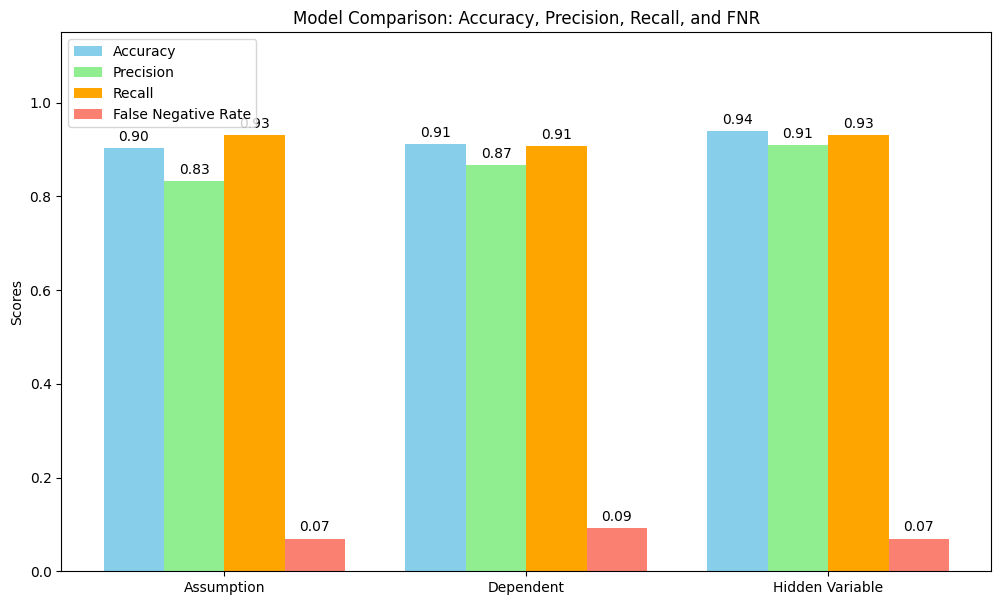

In [109]:
#Model Compairison
models = ['Assumption', 'Dependent', 'Hidden Variable']
accuracies = [accuracy_indep, accuracy_dep, accuracy_hv]
precisions = [precision_indep, precision_dep, precision_hv]
recalls = [recall_indep, recall_dep, recall_hv]
fnrs = [fnr_indep, fnr_dep, fnr_hv]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - 1.5*width, accuracies, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x - 0.5*width, precisions, width, label='Precision', color='lightgreen')
rects3 = ax.bar(x + 0.5*width, recalls, width, label='Recall', color='orange')
rects4 = ax.bar(x + 1.5*width, fnrs, width, label='False Negative Rate', color='salmon')

ax.set_ylabel('Scores')
ax.set_title('Model Comparison: Accuracy, Precision, Recall, and FNR')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

ax.bar_label(rects1, padding=3, fmt='%.2f')
ax.bar_label(rects2, padding=3, fmt='%.2f')
ax.bar_label(rects3, padding=3, fmt='%.2f')
ax.bar_label(rects4, padding=3, fmt='%.2f')

plt.ylim(0, 1.15)
plt.show()

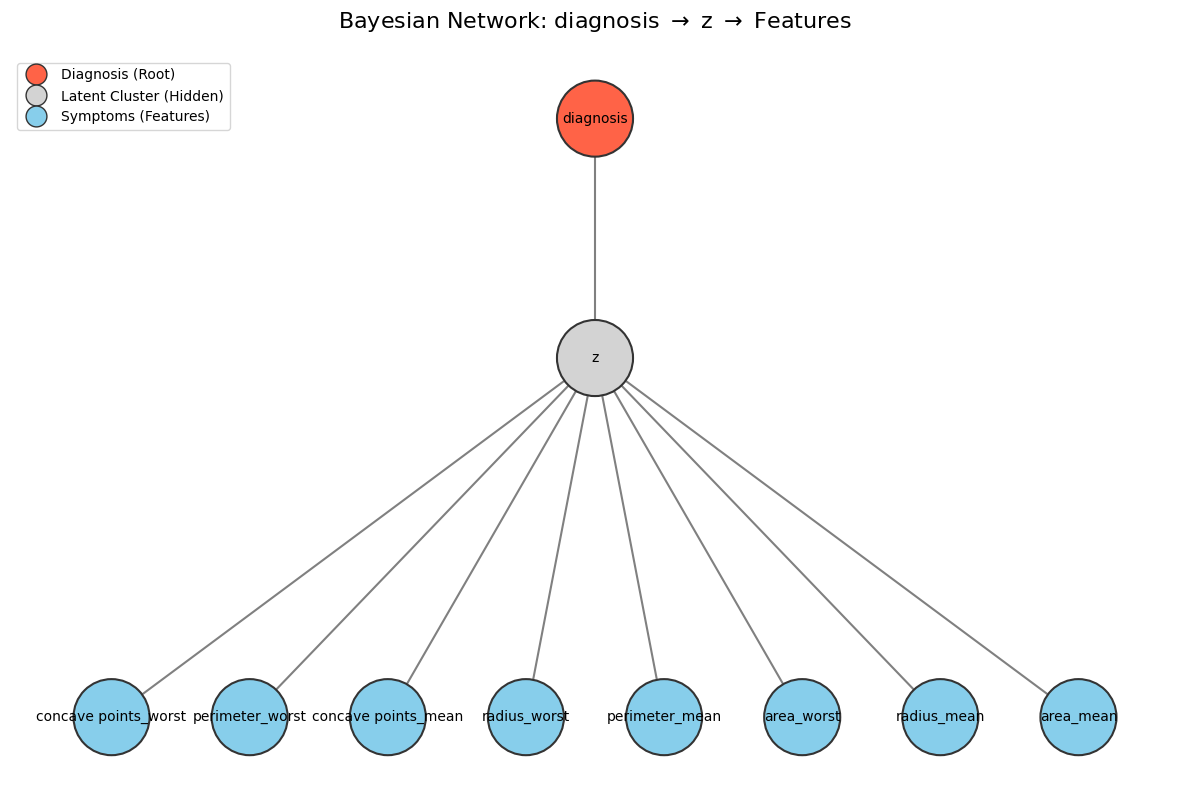

In [106]:
def plot_hv_model(model, figsize=(14, 8), node_size=3000, font_size=10):   
    root_node = model.root_node
    hidden_node = model.hidden_cluster_node[0] if model.hidden_cluster_node else "Hidden_State"
    feature_nodes = model.features
    
    # create directed graph
    G = nx.DiGraph()
    
    # add edge: Root -> Hidden
    G.add_edge(root_node, hidden_node)
    
    # add edges: Hidden -> Features
    for feature in feature_nodes:
        G.add_edge(hidden_node, feature)
        
    pos = {} # set position for each node
    pos[root_node] = np.array([0.5, 1.0])
    pos[hidden_node] = np.array([0.5, 0.6])
    
    # Third layer: Features - bottom, evenly distributed
    n_features = len(feature_nodes)
    if n_features > 0:
        # Evenly distribute feature nodes in the x=[0.05, 0.95] range
        x_vals = np.linspace(0.05, 0.95, n_features)
        for i, node in enumerate(feature_nodes):
            pos[node] = np.array([x_vals[i], 0.0])
            
    plt.figure(figsize=figsize)

    node_colors = []
    for node in G.nodes():
        if node == root_node:
            node_colors.append('#FF6347')  # Tomato Red
        elif node == hidden_node:
            node_colors.append('#D3D3D3')  # Light Grey
        else:
            node_colors.append('#87CEEB')  # Sky Blue
    

    nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_colors, 
                           edgecolors='#333333', linewidths=1.5)
    nx.draw_networkx_labels(G, pos, font_size=font_size, font_family='sans-serif')
    nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=20, 
                           edge_color='gray', width=1.5)
    
    # add legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Diagnosis (Root)',
               markerfacecolor='#FF6347', markersize=15, markeredgecolor='#333333'),
        Line2D([0], [0], marker='o', color='w', label='Latent Cluster (Hidden)',
               markerfacecolor='#D3D3D3', markersize=15, markeredgecolor='#333333'),
        Line2D([0], [0], marker='o', color='w', label='Symptoms (Features)',
               markerfacecolor='#87CEEB', markersize=15, markeredgecolor='#333333')
    ]
    
    plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, 1), frameon=True)
    plt.title(f"Bayesian Network: {root_node} $\\rightarrow$ {hidden_node} $\\rightarrow$ Features", fontsize=16, pad=20)
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_hv_model(hv_model, figsize=(12, 8), node_size=3000, font_size=10)